In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
print(Path().resolve().parents[0])

sys.path.append(str(Path().resolve().parents[0]))

from statsmodels.graphics.tsaplots import plot_acf

from src.data.loaders import load_prices
from src.portfolio.positions import Portfolio
from src.risk.volatility import _ewma_volatility
from src.risk.diagnostics import residual_diagnostics

/home/thomas/projects/quant-projects/risk-capital-engine


In [8]:
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META",
    "NVDA","JPM","UNH","XOM","PG"
]

prices = load_prices(
    tickers=tickers,
    start="2012-01-01",
    end="2025-12-31"
)

returns = prices.pct_change().dropna()

weights = np.ones(len(tickers)) / len(tickers)

portfolio = Portfolio(tickers=tickers, weights=weights, notional=10_000_000)

In [9]:
lambda_ = 0.94

vol = _ewma_volatility(returns, lambda_)

standardized = returns / vol

standardized = standardized.iloc[50:]   # burn-in

In [10]:
diagnostics = residual_diagnostics(standardized)

diagnostics

,asset,mean,variance,ljung_box_pvalue,ljung_box_sq_pvalue
0,AAPL,0.065234,1.148046,0.042607,0.958000
1,AMZN,0.066012,1.218408,0.855282,0.994895
2,GOOGL,0.071424,1.229862,0.283752,0.998945
3,JPM,0.061288,1.134316,0.348354,0.256925
4,META,0.063212,1.372277,0.454557,0.999277
5,MSFT,0.078223,1.168732,0.050631,0.938609
6,NVDA,0.093191,1.243389,0.553410,0.983708
7,PG,0.036185,1.148645,0.027427,0.709725
8,UNH,0.057766,1.172587,0.083705,0.966743
9,XOM,0.017233,1.097353,0.962375,0.025293


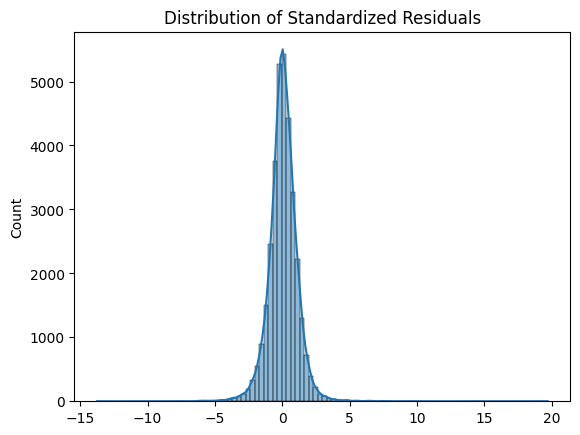

In [11]:
z = standardized.stack().to_numpy()

plt.figure()
sns.histplot(z, bins=100, kde=True)
plt.title("Distribution of Standardized Residuals")
plt.show()

### ACF Plots

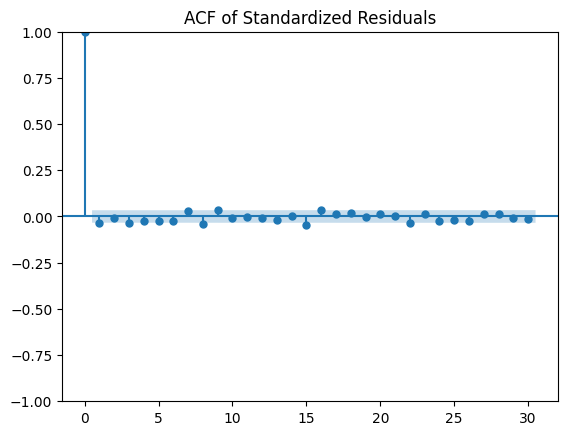

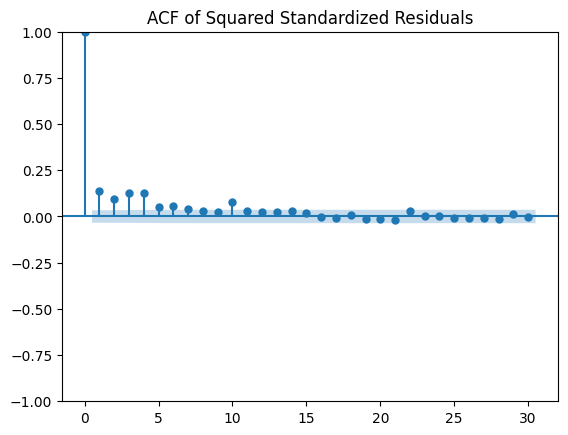

In [15]:
portfolio_resid = standardized @ portfolio.weights

plot_acf(portfolio_resid, lags=30)

plt.title("ACF of Standardized Residuals")
plt.show()

plot_acf(portfolio_resid**2, lags=30)

plt.title("ACF of Squared Standardized Residuals")
plt.show()

### EWMA volatility vs returns

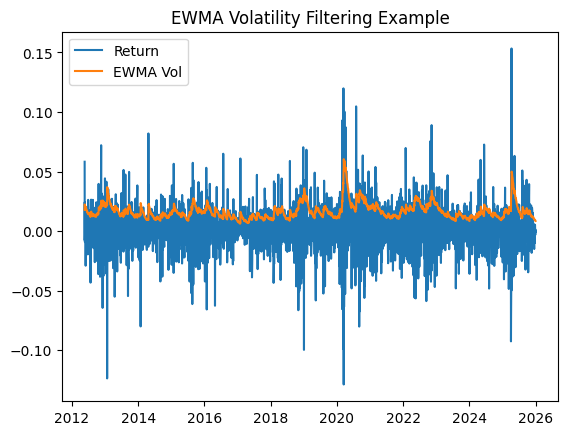

In [14]:
plt.figure()

plt.plot(returns.index, returns["AAPL"], label="Return")
plt.plot(vol.index, vol["AAPL"], label="EWMA Vol")

plt.legend()
plt.title("EWMA Volatility Filtering Example")

plt.show()

### Standardized Residuals vs Time

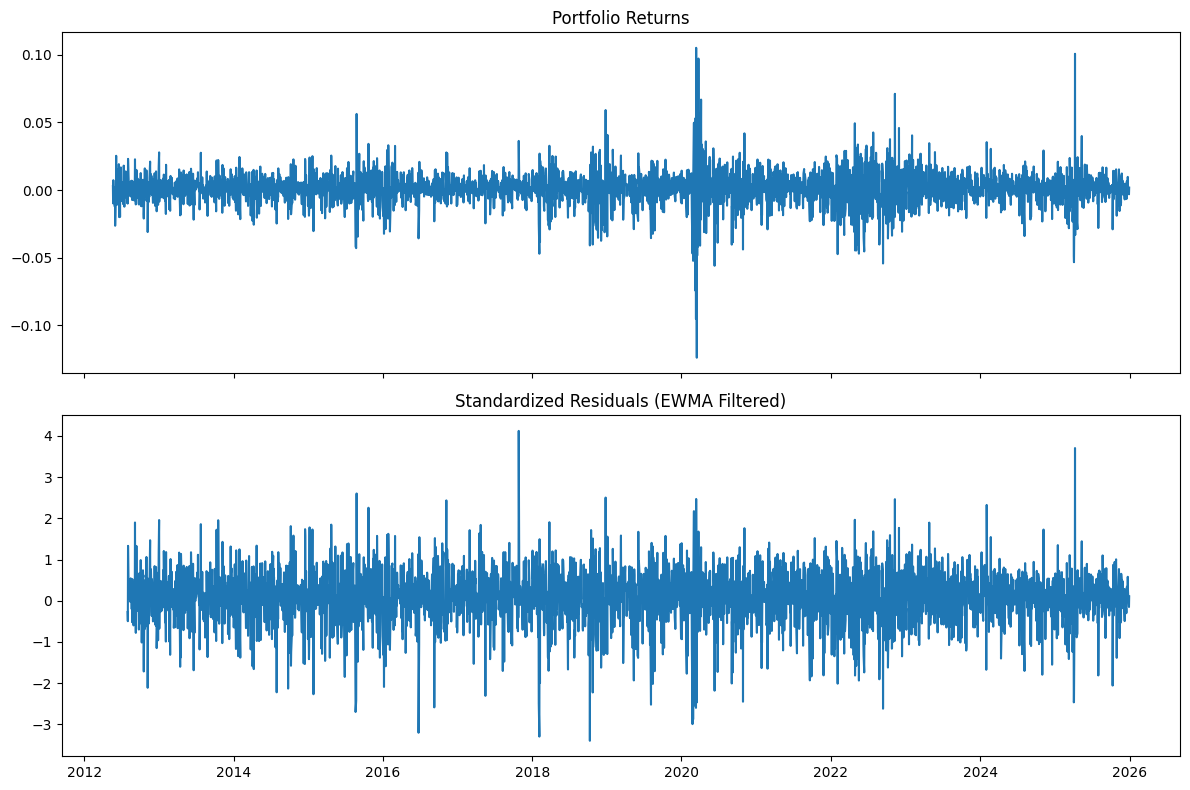

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

portfolio_returns = returns @ portfolio.weights
portfolio_resid = standardized @ portfolio.weights

ax[0].plot(portfolio_returns)
ax[0].set_title("Portfolio Returns")

ax[1].plot(portfolio_resid)
ax[1].set_title("Standardized Residuals (EWMA Filtered)")

plt.tight_layout()
plt.show()